In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

In [3]:
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir) + "/src")
sys.path.append(parent_dir)

In [4]:
from package_files.benefits_defns import *

In [5]:
from package_files.logit_model import *

In [6]:
# set font
plt.rcParams.update({'font.size': 14})

In [1]:
import polars as pl
usdf_salary = pl.scan_parquet('../../../../VData/scro4406/labeled_v1.parquet')

In [8]:
remote_kw = '../../../../VData/scro4406/data_v2.parquet'
remote_df = pl.scan_parquet(remote_kw)
usdf_salary = usdf_salary.join(remote_df.select(['ID', 'REMOTE_KW']), on='ID', how='left')

In [19]:
# rename usdf_salary
usdf = usdf_salary

In [20]:
usdf.select(pl.len()).collect()

len
u32
9872624


In [ ]:
# usdf['HAS_SALARY_INFO'] = usdf.apply(lambda x: 1 if pd.notnull(x['SALARY']) else 0, axis=1)

In [22]:
usdf = usdf \
    .with_columns(
        pl.col('SALARY').is_not_null().cast(pl.Int8).alias('HAS_SALARY_INFO')
    )

In [ ]:
# usdf['HAS_SALARY_INFO'] = np.where(usdf['SALARY'].notnull(), 1, 0)

In [ ]:
# usdf.rename(columns = {'has_salary_info': 'HAS_SALARY_INFO'}, inplace=True)

In [13]:
benefits4

['EDU_ASSISTANCE',
 'PAID LEAVE',
 'HEALTH_WELLBEING',
 'PARENTAL_LEAVE',
 'CULTURE',
 'REMOTE_KW']

In [14]:
benefit_colors

{'EDU_ASSISTANCE': '#41afaa',
 'PAID LEAVE': '#466eb4',
 'HEALTH_WELLBEING': '#e6a532',
 'PARENTAL_LEAVE': '#00a0e1',
 'CULTURE': '#d7642c',
 'wfh_wham': '#af4b91',
 'REMOTE_KW': '#c765a6'}

In [25]:
usdf = usdf \
    .select(
        pl.col("YEAR"),
        pl.col("AI ROLE"),
        pl.col("HAS_SALARY_INFO"),
        pl.col("EDU_ASSISTANCE"),
        pl.col("PAID LEAVE"),
        pl.col("HEALTH_WELLBEING"),
        pl.col("PARENTAL_LEAVE"),
        pl.col("CULTURE"),
        pl.col("REMOTE_KW"),
    ).collect().to_pandas()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             28 non-null     int16  
 1   AI ROLE          28 non-null     bool   
 2   EDU_ASSISTANCE   28 non-null     bool   
 3   HAS_SALARY_INFO  28 non-null     float64
dtypes: bool(2), float64(1), int16(1)
memory usage: 468.0 bytes
None
[2018 2019 2020 2021 2022 2023 2024]
YEAR               0
AI ROLE            0
EDU_ASSISTANCE     0
HAS_SALARY_INFO    0
dtype: int64


,YEAR,AI ROLE,EDU_ASSISTANCE,HAS_SALARY_INFO
0,2018,False,False,0.162441
1,2018,False,True,0.154696
2,2018,True,False,0.094031
3,2018,True,True,0.080153
4,2019,False,False,0.183398


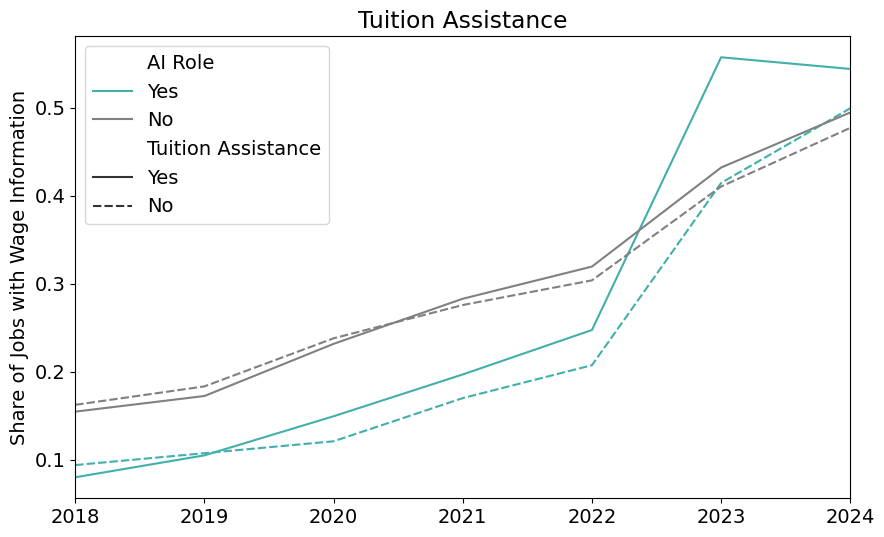

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             28 non-null     int16  
 1   AI ROLE          28 non-null     bool   
 2   PAID LEAVE       28 non-null     bool   
 3   HAS_SALARY_INFO  28 non-null     float64
dtypes: bool(2), float64(1), int16(1)
memory usage: 468.0 bytes
None
[2018 2019 2020 2021 2022 2023 2024]
YEAR               0
AI ROLE            0
PAID LEAVE         0
HAS_SALARY_INFO    0
dtype: int64


,YEAR,AI ROLE,PAID LEAVE,HAS_SALARY_INFO
0,2018,False,False,0.151390
1,2018,False,True,0.249790
2,2018,True,False,0.081935
3,2018,True,True,0.210440
4,2019,False,False,0.167674


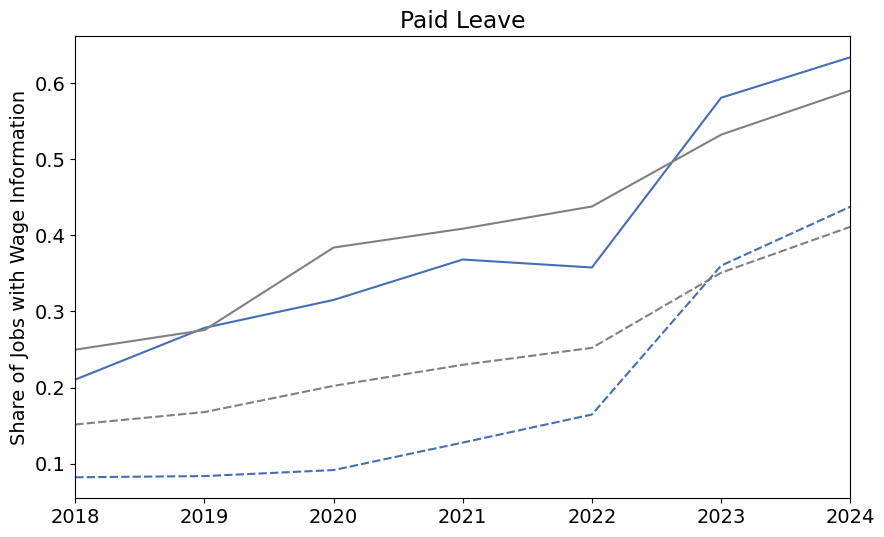

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              28 non-null     int16  
 1   AI ROLE           28 non-null     bool   
 2   HEALTH_WELLBEING  28 non-null     bool   
 3   HAS_SALARY_INFO   28 non-null     float64
dtypes: bool(2), float64(1), int16(1)
memory usage: 468.0 bytes
None
[2018 2019 2020 2021 2022 2023 2024]
YEAR                0
AI ROLE             0
HEALTH_WELLBEING    0
HAS_SALARY_INFO     0
dtype: int64


,YEAR,AI ROLE,HEALTH_WELLBEING,HAS_SALARY_INFO
0,2018,False,False,0.160955
1,2018,False,True,0.215294
2,2018,True,False,0.093246
3,2018,True,True,0.107438
4,2019,False,False,0.182401


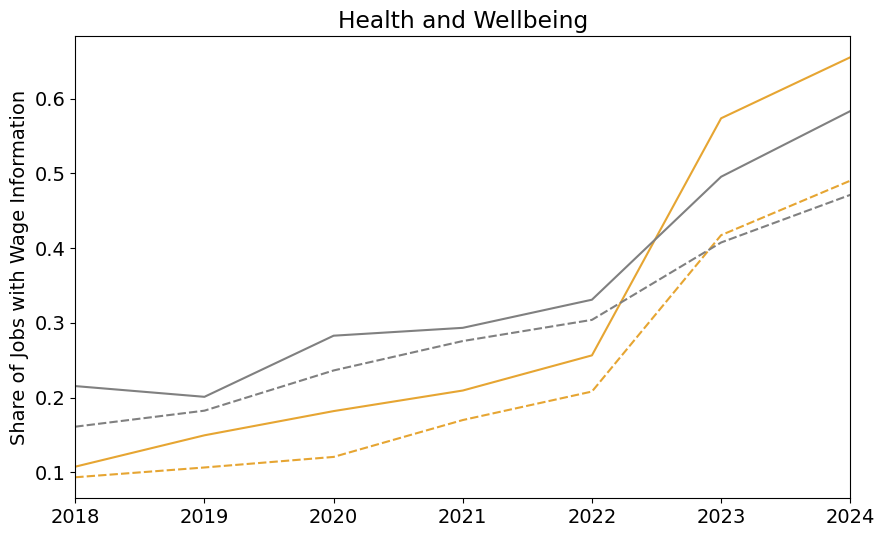

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             28 non-null     int16  
 1   AI ROLE          28 non-null     bool   
 2   PARENTAL_LEAVE   28 non-null     bool   
 3   HAS_SALARY_INFO  28 non-null     float64
dtypes: bool(2), float64(1), int16(1)
memory usage: 468.0 bytes
None
[2018 2019 2020 2021 2022 2023 2024]
YEAR               0
AI ROLE            0
PARENTAL_LEAVE     0
HAS_SALARY_INFO    0
dtype: int64


,YEAR,AI ROLE,PARENTAL_LEAVE,HAS_SALARY_INFO
0,2018,False,False,0.162323
1,2018,False,True,0.120582
2,2018,True,False,0.093477
3,2018,True,True,0.096154
4,2019,False,False,0.182379


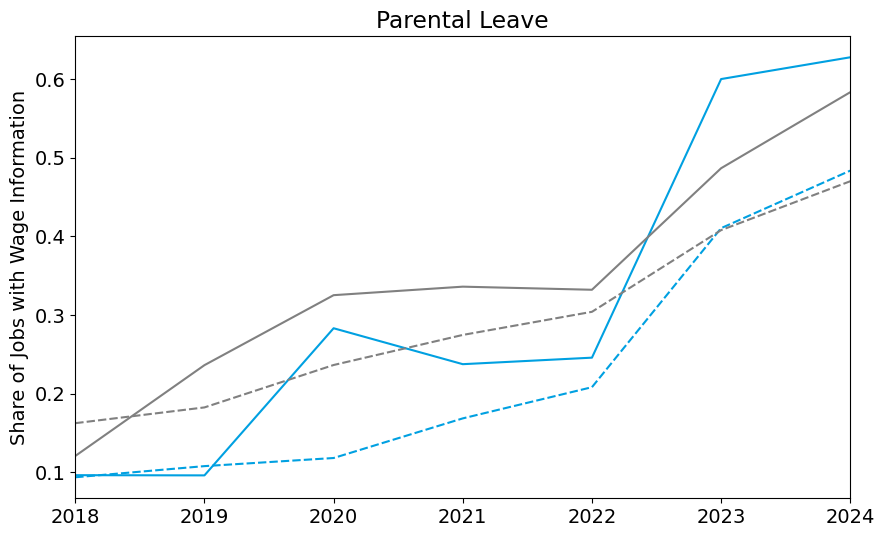

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             28 non-null     int16  
 1   AI ROLE          28 non-null     bool   
 2   CULTURE          28 non-null     bool   
 3   HAS_SALARY_INFO  28 non-null     float64
dtypes: bool(2), float64(1), int16(1)
memory usage: 468.0 bytes
None
[2018 2019 2020 2021 2022 2023 2024]
YEAR               0
AI ROLE            0
CULTURE            0
HAS_SALARY_INFO    0
dtype: int64


,YEAR,AI ROLE,CULTURE,HAS_SALARY_INFO
0,2018,False,False,0.165169
1,2018,False,True,0.095173
2,2018,True,False,0.098117
3,2018,True,True,0.040367
4,2019,False,False,0.187095


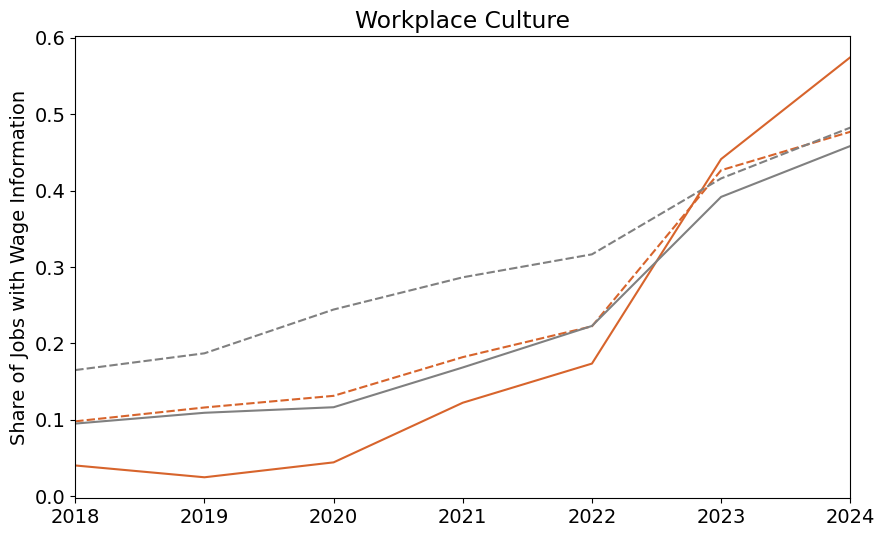

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             28 non-null     int16  
 1   AI ROLE          28 non-null     bool   
 2   REMOTE_KW        28 non-null     bool   
 3   HAS_SALARY_INFO  28 non-null     float64
dtypes: bool(2), float64(1), int16(1)
memory usage: 468.0 bytes
None
[2018 2019 2020 2021 2022 2023 2024]
YEAR               0
AI ROLE            0
REMOTE_KW          0
HAS_SALARY_INFO    0
dtype: int64


,YEAR,AI ROLE,REMOTE_KW,HAS_SALARY_INFO
0,2018,False,False,0.160157
1,2018,False,True,0.233932
2,2018,True,False,0.090222
3,2018,True,True,0.158055
4,2019,False,False,0.177644


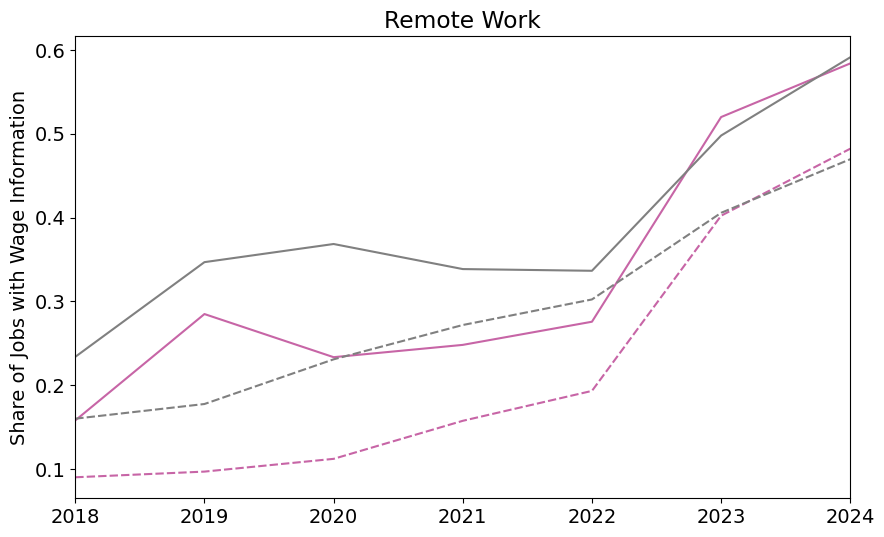

In [26]:
for benefit in benefits4:
    grouped = usdf.groupby(['YEAR','AI ROLE', benefit])['HAS_SALARY_INFO'].mean().reset_index()
    grouped['HAS_SALARY_INFO'] = pd.to_numeric(grouped['HAS_SALARY_INFO'], errors='coerce')
    print(grouped.info())
    grouped['YEAR'] = pd.to_numeric(grouped['YEAR'], errors = 'coerce')
    grouped['YEAR'].unique()
    grouped['AI ROLE'] = grouped['AI ROLE'].astype(str)
    grouped[benefit] = grouped[benefit].astype(str)
    grouped = grouped.sort_values('YEAR')
    print(grouped['YEAR'].unique())
    print(grouped.isnull().sum())
    palette = [benefit_colors[benefit], 'gray']
    display(grouped.head())
    
    plt.figure(figsize = (10,6))
    sns.lineplot(
        data = grouped,
        x = 'YEAR', 
        y = 'HAS_SALARY_INFO', 
        hue = 'AI ROLE',
        style = benefit,
        # markers=False,
        errorbar = None, 
        palette=palette,
        style_order = ['True', 'False'],
        hue_order=['True','False']
    )
    plt.xticks(grouped['YEAR'].unique())
    plt.xlim(grouped['YEAR'].min(), grouped['YEAR'].max())
    handles, labels = plt.gca().get_legend_handles_labels()
    new_handles = handles
    new_labels = ['AI Role', 'Yes','No', f'{benefits_labels_map[benefit]}','Yes','No']
    if benefit == benefits4[0]:
        plt.legend(handles = new_handles, labels = new_labels, loc='upper left')
    else: 
        plt.legend().remove()
    plt.xlabel(None)
    plt.ylabel('Share of Jobs with Wage Information')    
    plt.title(benefits_labels_map[benefit])
    fig_path = '../figures/salary/wage_info'
    if not os.path.exists(fig_path):
        os.makedirs(fig_path)
    plt.savefig(fig_path + f'/wage_info_{benefit}.png')
    plt.show()

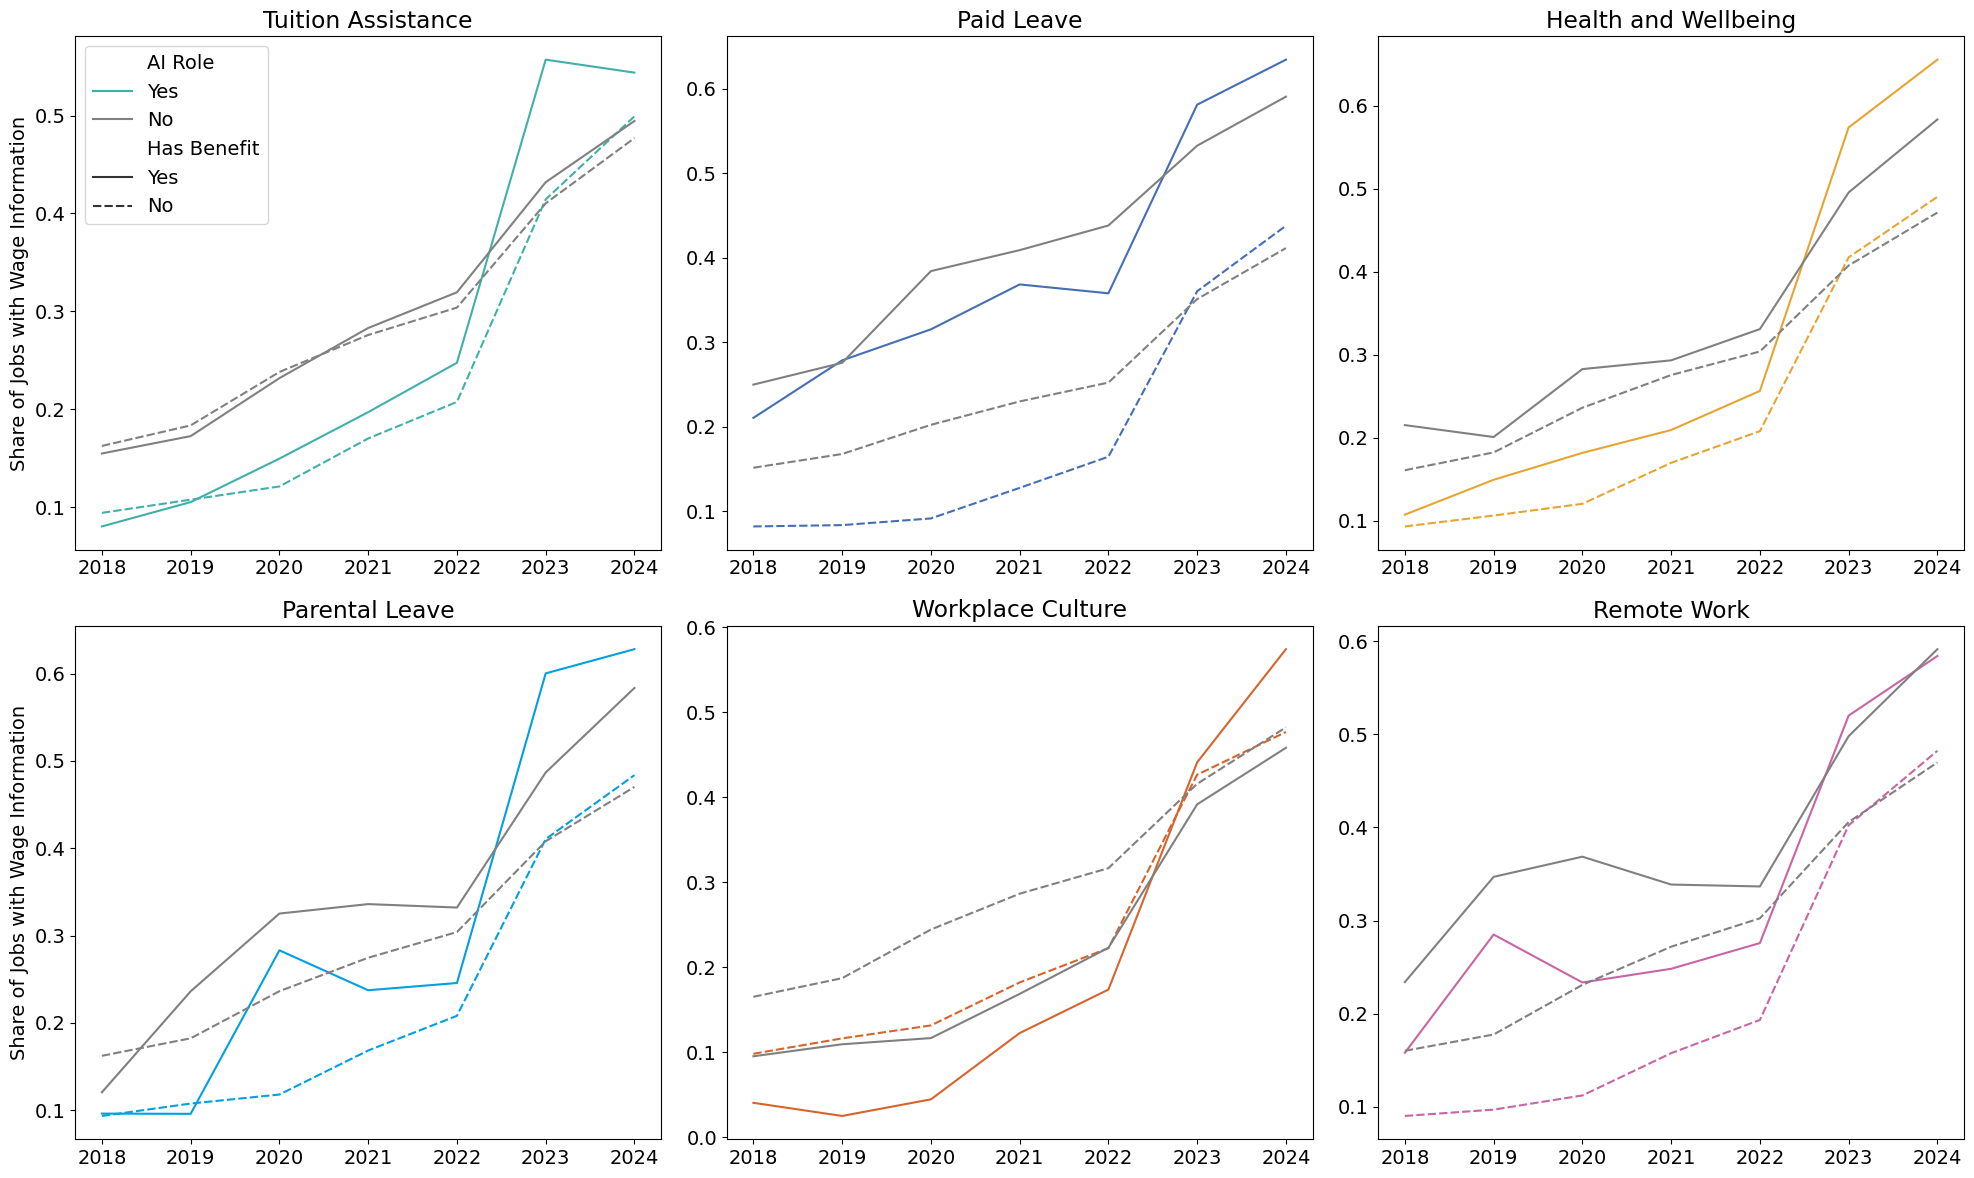

In [27]:
# Define the number of rows and columns for subplots
nrows = 2
ncols = 3

# Set up the overall figure
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 12))
axes = axes.flatten()  # Flatten to easily index axes

for i, benefit in enumerate(benefits4):
    ax = axes[i]
    grouped = usdf.groupby(['YEAR','AI ROLE', benefit])['HAS_SALARY_INFO'].mean().reset_index()
    grouped['HAS_SALARY_INFO'] = pd.to_numeric(grouped['HAS_SALARY_INFO'], errors='coerce')
    # print(grouped.info())
    grouped['YEAR'] = pd.to_numeric(grouped['YEAR'], errors = 'coerce')
    grouped['YEAR'].unique()
    grouped['AI ROLE'] = grouped['AI ROLE'].astype(str)
    grouped[benefit] = grouped[benefit].astype(str)
    grouped = grouped.sort_values('YEAR')
    # print(grouped['YEAR'].unique())
    # print(grouped.isnull().sum())
    palette = [benefit_colors[benefit], 'gray']
    # display(grouped.head())
    
    sns.lineplot(
        data = grouped,
        x = 'YEAR', 
        y = 'HAS_SALARY_INFO', 
        hue = 'AI ROLE',
        style = benefit,
        # markers=False,
        errorbar = None, 
        palette=palette,
        style_order = ['True', 'False'],
        hue_order=['True','False'], 
        ax = ax
    )
    ax.set_xticks(grouped['YEAR'].unique())
    ax.set_xlabel(None)
    if i == 0 or i == 3:
        ax.set_ylabel('Share of Jobs with Wage Information')
    else:
        ax.set_ylabel(None)
    ax.set_title(benefits_labels_map[benefit])

    # Customize legend for each subplot
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        new_labels = ['AI Role', 'Yes', 'No', "Has Benefit", 'Yes', 'No']
        ax.legend(handles=handles, labels=new_labels, loc='upper left')
    else:
        ax.legend().remove()
    
plt.tight_layout()
plt.savefig(fig_path + '/wage_info_all.png')
plt.show()


# Models

In [32]:
models = []
model_data = usdf[usdf['YEAR'] == 2023]
for benefit in benefits4:
    model = run_logit_model(data = model_data, dependent = 'HAS_SALARY_INFO', predictor = 'AI ROLE', binary_vars = [benefit])
    models.append(model)
    model.summary()

Number of NAs in dependent: 0
Optimization terminated successfully.
         Current function value: 0.677774
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:        HAS_SALARY_INFO   No. Observations:              1418842
Model:                          Logit   Df Residuals:                  1418839
Method:                           MLE   Df Model:                            2
Date:                Sun, 28 Sep 2025   Pseudo R-squ.:               0.0001499
Time:                        15:40:55   Log-Likelihood:            -9.6165e+05
converged:                       True   LL-Null:                   -9.6180e+05
Covariance Type:            nonrobust   LLR p-value:                 2.410e-63
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.3626      0.002   -200.028      0.000      -0.366

In [33]:
stargazer = Stargazer(models)
stargazer.render_latex()



'\\begin{table}[!htbp] \\centering\n\\begin{tabular}{@{\\extracolsep{5pt}}lcccccc}\n\\\\[-1.8ex]\\hline\n\\hline \\\\[-1.8ex]\n& \\multicolumn{6}{c}{\\textit{Dependent variable: HAS_SALARY_INFO}} \\\n\\cr \\cline{2-7}\n\\\\[-1.8ex] & (1) & (2) & (3) & (4) & (5) & (6) \\\\\n\\hline \\\\[-1.8ex]\n AI ROLE & 0.070$^{***}$ & 0.092$^{***}$ & 0.063$^{***}$ & 0.057$^{**}$ & 0.080$^{***}$ & 0.010$^{}$ \\\\\n& (0.023) & (0.023) & (0.023) & (0.023) & (0.023) & (0.023) \\\\\n CULTURE & & & & & -0.099$^{***}$ & \\\\\n& & & & & (0.005) & \\\\\n EDU_ASSISTANCE & 0.091$^{***}$ & & & & & \\\\\n& (0.005) & & & & & \\\\\n HEALTH_WELLBEING & & & 0.358$^{***}$ & & & \\\\\n& & & (0.007) & & & \\\\\n PAID LEAVE & & 0.746$^{***}$ & & & & \\\\\n& & (0.004) & & & & \\\\\n PARENTAL_LEAVE & & & & 0.323$^{***}$ & & \\\\\n& & & & (0.007) & & \\\\\n REMOTE_KW & & & & & & 0.375$^{***}$ \\\\\n& & & & & & (0.006) \\\\\n const & -0.363$^{***}$ & -0.615$^{***}$ & -0.374$^{***}$ & -0.372$^{***}$ & -0.340$^{***}$ & -0.382

In [34]:
with open(f'../exports/tables/wage_info_2023.tex', 'w') as f:
    f.write(stargazer.render_latex())

FileNotFoundError: [Errno 2] No such file or directory: '../exports/tables/wage_info_2023.tex'

In [ ]:
display(HTML(stargazer.render_html()))

In [ ]:
usdf[usdf['AI ROLE']==True]

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,EDU_ASSISTANCE,PAID_LEAVE,WELLBEING,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,REMOTE_KW,EXPERIENCE_BUCKET,LOG_SALARY,HAS_SALARY_INFO
128,2d0820331da990677cf77d3783154bd85bb53af4,"Flowery Branch, GA","Hall, GA",Georgia,99,Unclassified Industry,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,3-5 years,NaN,0
182,f556cbda366e9d0b2771fd4019fd2e6f088f2896,"Miami, FL","Miami-Dade, FL",Florida,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,True,True,3-5 years,NaN,0
187,fabd120b46616c18c8fea9c6005c13089081d0df,"Austin, TX","Williamson, TX",Texas,54,"Professional, Scientific, and Technical Services",Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,6-10 years,NaN,0
244,39cd7682488f13bd227c68f1c3d9ce835fa982ee,"Little Rock, AR","Pulaski, AR",Arkansas,44,Retail Trade,No Education Listed,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,True,3-5 years,NaN,0
256,32112b12427b335ba8c7d703b8a4def02a551725,"Tampa, FL","Hillsborough, FL",Florida,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,3-5 years,11.950922,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9872495,d295fdb9b20071ad1b70d3d9e19b544b56e0b742,"Tukwila, WA","King, WA",Washington,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,True,False,6-10 years,NaN,0
9872638,8872bc2cdefa891c1dc931d99aa09168afd57504,"Wright-Patterson Air Force Base, OH","Greene, OH",Ohio,54,"Professional, Scientific, and Technical Services",Associate degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,11-20 years,NaN,0
9872696,6b6d64a0a35b38b1d80d1797dd5d2a3c3d3a9629,"North Chicago, IL","Lake, IL",Illinois,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,3-5 years,NaN,0
9872890,c77b918f92613d85a300bd67f026291a17915585,"Knoxville, TN","Knox, TN",Tennessee,52,Finance and Insurance,Bachelor's degree,1,Full-time (> 32 hours),False,...,False,False,False,False,False,False,False,6-10 years,NaN,0


## Only AI Roles

In [ ]:
models2 = []
model_data_ai = usdf[(usdf['YEAR'] == 2023) & ( usdf['AI ROLE'] == True)]
for benefit in benefits4:
    model = run_logit_model(data = model_data_ai, dependent = 'HAS_SALARY_INFO', predictor = benefit)
    models2.append(model)
    model.summary()

Number of NAs in dependent: 0
Optimization terminated successfully.
         Current function value: 0.678097
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:        HAS_SALARY_INFO   No. Observations:                17766
Model:                          Logit   Df Residuals:                    17764
Method:                           MLE   Df Model:                            1
Date:                Mon, 09 Dec 2024   Pseudo R-squ.:                0.002751
Time:                        20:53:33   Log-Likelihood:                -12047.
converged:                       True   LL-Null:                       -12080.
Covariance Type:            nonrobust   LLR p-value:                 3.555e-16
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.3734      0.016    -22.925      0.000      -0.405

In [ ]:
stargazer = Stargazer(models2)
stargazer.render_latex()

'\\begin{table}[!htbp] \\centering\n\\begin{tabular}{@{\\extracolsep{5pt}}lcccccc}\n\\\\[-1.8ex]\\hline\n\\hline \\\\[-1.8ex]\n& \\multicolumn{6}{c}{\\textit{Dependent variable: HAS_SALARY_INFO}} \\\n\\cr \\cline{2-7}\n\\\\[-1.8ex] & (1) & (2) & (3) & (4) & (5) & (6) \\\\\n\\hline \\\\[-1.8ex]\n CULTURE & & & & & 0.046$^{}$ & \\\\\n& & & & & (0.035) & \\\\\n EDU_ASSISTANCE & 0.376$^{***}$ & & & & & \\\\\n& (0.046) & & & & & \\\\\n HEALTH_WELLBEING & & & 0.722$^{***}$ & & & \\\\\n& & & (0.058) & & & \\\\\n PAID_LEAVE & & 0.928$^{***}$ & & & & \\\\\n& & (0.034) & & & & \\\\\n PARENTAL_LEAVE & & & & 0.792$^{***}$ & & \\\\\n& & & & (0.047) & & \\\\\n REMOTE_KW & & & & & & 0.496$^{***}$ \\\\\n& & & & & & (0.035) \\\\\n const & -0.373$^{***}$ & -0.599$^{***}$ & -0.381$^{***}$ & -0.426$^{***}$ & -0.339$^{***}$ & -0.454$^{***}$ \\\\\n& (0.016) & (0.019) & (0.016) & (0.016) & (0.018) & (0.018) \\\\\n\\hline \\\\[-1.8ex]\n Observations & 17766 & 17766 & 17766 & 17766 & 17766 & 17766 \\\\\n Pseud

In [ ]:
display(HTML(stargazer.render_html()))

In [ ]:
with open(f'../exports/tables/wage_info_2023_ai.tex', 'w') as f:
    f.write(stargazer.render_latex())